# Linear & Logistic Regression — From Scratch and with scikit-learn
Dataset: `house_prices_practice.csv`

Import the libraries used throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the housing dataset into a DataFrame.

In [2]:
df = pd.read_csv('house_prices_practice.csv')

Preview the first 5 rows.

In [3]:
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


Preview the last 5 rows.

In [4]:
df.tail()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345
299,300,9,1667,0,988,1958,2,1,14553,204982


Check the number of rows and columns.

In [5]:
df.shape

(300, 10)

Check column data types and non-null counts.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


Get summary statistics (mean, min, max, etc.) for every numeric column.

In [7]:
df.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


Check for missing values in each column.

In [8]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


Check for duplicate rows.

In [9]:
print(df.duplicated().sum())

0


## Linear Regression

### From Scratch (single feature: GrLivArea)

Extract `GrLivArea` as x and `SalePrice` as y, then standardize x (mean 0, spread 1) so gradient descent trains smoothly.

In [10]:
x = df['GrLivArea'].values
y = df['SalePrice'].values

x_norm = (x - x.mean()) / x.std()

Train with gradient descent: repeatedly update `theta0` and `theta1` to reduce the cost.

In [11]:
m = len(y)
theta0, theta1 = 0.0, 0.0
alpha = 0.1
iterations = 500

for i in range(iterations):
    y_pred = theta0 + theta1 * x_norm
    error = y_pred - y
    theta0 -= alpha * (1/m) * np.sum(error)
    theta1 -= alpha * (1/m) * np.sum(error * x_norm)

print("theta0:", theta0)
print("theta1:", theta1)

theta0: 252262.9033333332
theta1: 55787.429053286345


Plot the data points with the fitted line.

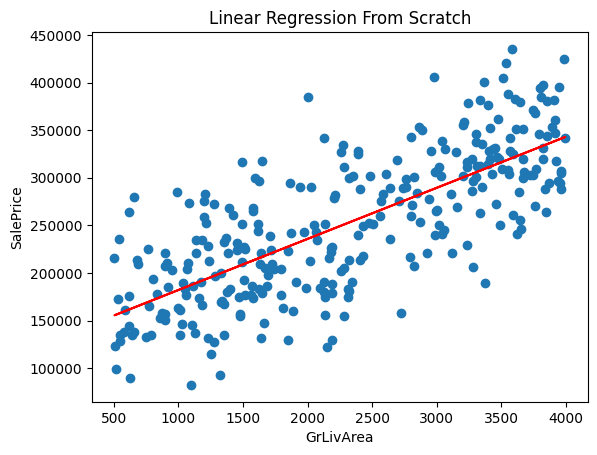

In [12]:
plt.scatter(x, y)
plt.plot(x, theta0 + theta1 * x_norm, color='red')
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Linear Regression From Scratch")
plt.show()

### Using scikit-learn (all features)

Import scikit-learn's tools for splitting data, modeling, and scoring.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

Separate the features (X) from the target (y). `Id` is just a row number, so it's dropped along with the target itself.

In [14]:
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

Split into a training set (80%) and a test set (20%) the model never trains on.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a linear regression model on the training data.

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predict prices for the test houses.

In [17]:
y_pred = model.predict(X_test)

Compare actual vs predicted prices, house by house.

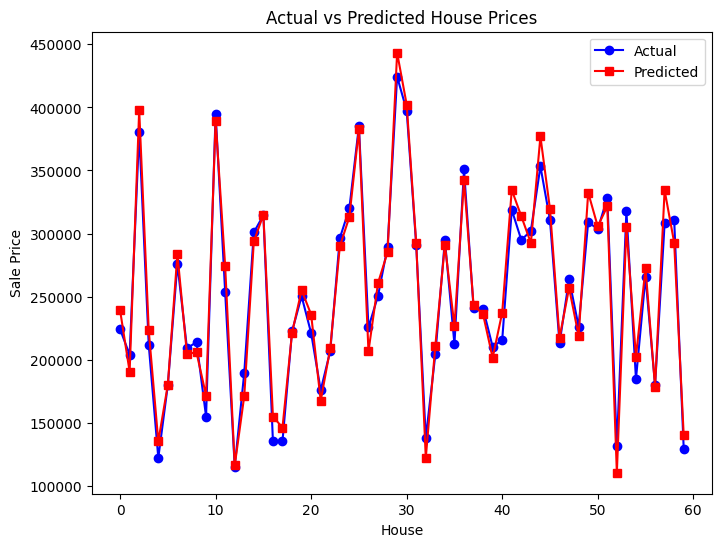

In [18]:
plt.figure(figsize=(8,6))
plt.plot(y_test.values, color='blue', marker='o', label='Actual')
plt.plot(y_pred, color='red', marker='s', label='Predicted')
plt.xlabel("House")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

Evaluate the model with R² (variance explained), MAE, and RMSE (both in dollars).

In [19]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R² Score:", round(r2, 4))
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))

R² Score: 0.9724
MAE: 10431.656
RMSE: 12505.4593


## Logistic Regression

Create a binary target: `Expensive` = 1 if a house's price is above the median, else 0.

In [20]:
df['Expensive'] = (df['SalePrice'] > df['SalePrice'].median()).astype(int)
df[['SalePrice', 'Expensive']].head()

,SalePrice,Expensive
0,177106,0
1,301044,1
2,360609,1
3,240556,0
4,193656,0


### From Scratch (single feature: GrLivArea)

Standardize `GrLivArea` again and define the sigmoid function, which squeezes any number into a 0–1 probability.

In [21]:
x = df['GrLivArea'].values
y = df['Expensive'].values

x_norm = (x - x.mean()) / x.std()

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

Train with gradient descent — same update rule as linear regression, but `h(x)` is now passed through the sigmoid.

In [22]:
m = len(y)
theta0, theta1 = 0.0, 0.0
alpha = 0.1
iterations = 1000

for i in range(iterations):
    z = theta0 + theta1 * x_norm
    h = sigmoid(z)
    error = h - y
    theta0 -= alpha * (1/m) * np.sum(error)
    theta1 -= alpha * (1/m) * np.sum(error * x_norm)

print("theta0:", theta0)
print("theta1:", theta1)

theta0: 0.005115646761569864
theta1: 1.8718173854638853


Plot the data points (0 = not expensive, 1 = expensive) with the fitted sigmoid curve — the logistic-regression equivalent of the best-fit line. `x` is sorted first so the curve draws smoothly left to right.

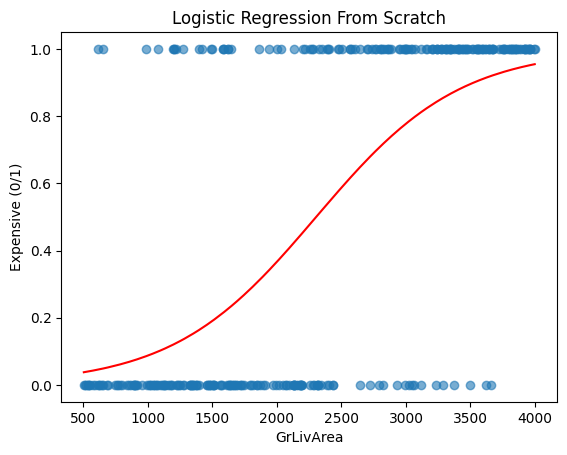

In [23]:
x_sorted = np.sort(x)
x_sorted_norm = (x_sorted - x.mean()) / x.std()
y_curve = sigmoid(theta0 + theta1 * x_sorted_norm)

plt.scatter(x, y, alpha=0.6)
plt.plot(x_sorted, y_curve, color='red')
plt.xlabel("GrLivArea")
plt.ylabel("Expensive (0/1)")
plt.title("Logistic Regression From Scratch")
plt.show()

### Using scikit-learn (all features)

Separate features/target and split into train/test sets, same as the linear regression section.

In [24]:
X = df.drop(['Id', 'SalePrice', 'Expensive'], axis=1)
y = df['Expensive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a logistic regression model on the training data.

In [25]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Predict classes for the test houses and check accuracy.

In [26]:
y_pred = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.95
